In [1]:
import time

import py4hw
import py4hw.external.platforms.terasic as terasic
import py4hw.external.wsl.edalize as wsl

In [2]:
hw = terasic.DE10_Lite()

pb = hw.getSwitches()
led = hw.getLEDs()

for i in range(10):
    py4hw.Buf(hw, f'pb{i}', pb[i], led[i])

Initial /DE10_Lite[DE10_Lite] {'clk': <py4hw.base.Wire object at 0x00000293AC0F0AD0>, 'MAX10_CLK1_50': <py4hw.base.Wire object at 0x00000293AC086990>}


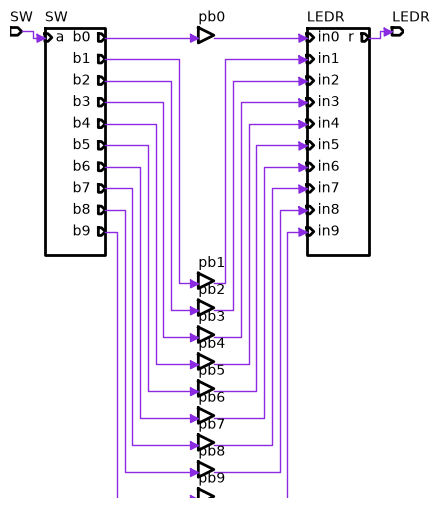

In [3]:
py4hw.Schematic(hw).draw()

In [4]:
if (True):
    BASH = r"bash.exe"
    QUARTUS_PATH = r"C:\altera_lite\25.1std\quartus\bin64"
    project_dir = r"C:\temp\test_de11_lite"
    wsl.patch_edalize_for_quartus_project(project_dir, QUARTUS_PATH, BASH, verbose=True)
    

PATCHING QUARTUS


In [5]:
t0 = time.time()

hw.build(project_dir)
tf = time.time()
print('BUILT OK', tf-t0, 'seconds')
py4hw.Sound.beep(duration=1)

Creating the directory C:\temp\test_de11_lite


Unable to recognise Quartus version via quartus_sh


Configure Edalize
RENDER TEMPLATE quartus-std-makefile.j2
PATCHED makefile
# Auto generated by Edalize
NAME := DE10_Lite
OPTIONS := --64bit
DSE_OPTIONS := 

all: sta

project: $(NAME).tcl
	$(EDALIZE_LAUNCHER) /mnt/c/altera_lite/25.1std/quartus/bin64/quartus_sh.exe $(OPTIONS) -t $(NAME).tcl

qsys: project

syn: qsys
	$(EDALIZE_LAUNCHER) /mnt/c/altera_lite/25.1std/quartus/bin64/quartus_map.exe $(OPTIONS) $(NAME)

fit: syn
	$(EDALIZE_LAUNCHER) /mnt/c/altera_lite/25.1std/quartus/bin64/quartus_fit.exe $(OPTIONS) $(NAME)

asm: fit
	$(EDALIZE_LAUNCHER) /mnt/c/altera_lite/25.1std/quartus/bin64/quartus_asm.exe $(OPTIONS) $(NAME)

sta: asm
	$(EDALIZE_LAUNCHER) /mnt/c/altera_lite/25.1std/quartus/bin64/quartus_sta.exe $(OPTIONS) $(NAME)

dse: syn
	$(EDALIZE_LAUNCHER) /mnt/c/altera_lite/25.1std/quartus/bin64/quartus_dse.exe $(NAME) $(DSE_OPTIONS)

clean:
	$(EDALIZE_LAUNCHER) rm -rf *.* db incremental_db

.PHONY: all project qsys syn fit asm sta dse clean


RENDER TEMPLATE quartus-project.tcl.j2
Bui

In [6]:
hw.download(project_dir)
tf = time.time()
print('DOWNLOAD', tf-t0, 'seconds')
py4hw.Sound.beep(duration=1)

Unable to recognise Quartus version via quartus_sh


Download bitstream
RUN: quartus_pgm (['--mode=jtag', '-o', 'p;DE10_Lite.sof'],) {}
Entering directory 'C:\temp\test_de11_lite'
Leaving directory 'C:\temp\test_de11_lite'
DOWNLOAD 28.21115255355835 seconds
